# Bài thực hành 1

## Vấn đề
_Dự đoán khả năng tiến triển của bệnh tiểu đường thông qua các chỉ số sinh lý của cơ thể._


## Thông tin dữ liệu:

- Số lượng mẫu: 442 (thông tin từ 442 bệnh nhân)
- Số lượng thuộc tính:
    Thông tin các thuộc tính (10 cột giá trị đầu tiên): Age(tuổi), Sex (giới tính),
    Body mass index (chỉ số khối cơ thể), Average blood pressure(huyết ap trung bình), S1, S2, S3, S4, S5, S6 (sáu phép đo huyết thanh khác).
- Mục tiêu:	Cột 11, chỉ số đánh giá mức độ tiến triển của bệnh 1 năm sau khi điều trị.

**! Chú ý: Dữ liệu thông tin thuộc tính đã được chuẩn hoá**

Xem thêm thông tin về nguồn dữ liệu tại: (https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html)


# Hướng giải quyết

Giả sử rằng khả năng tiến triển của bệnh tiểu đường (ký hiệu: `y`) là đại lượng phụ thuộc tuyến tính vào các thông tin sinh lý của bệnh nhân như các thuộc tính đã mô tả ở trên (tuổi, giới tính, chỉ số khối, ... - ký hiệu: `x1, x2, .. x_n`) :

`y = w0 + w1*x1 + w2*x2 + ... + w_n*x_n`

Mục tiêu: Tìm được bộ trọng số `[w0, w1, ... w_n]` biểu diễn mối quan hệ này.

#Các bước tiến hành

## Thư viện sử dụng

- matplotlib: phục vụ vẽ các đồ thị
- numpy: tính toán các phép biến đổi trên ma trận / vector
- math: thực hiện một số hàm tính toán
- pandas: phục vụ chuyển đổi trên dữ liệu dạng bảng
- scikit-learn: (sklearn) thư viện hỗ trợ xây dựng các mô hình học máy, các hàm training và testing.


In [1]:
!pip install pandas

zsh:1: command not found: pip


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score


## Đọc dữ liệu

Dữ liệu về bệnh tiểu đường được hỗ trợ bởi sklearn, đọc dữ liệu thông qua hàm `datasets.load_diabetes()`

Xem thêm các bộ dữ liệu khác tại https://scikit-learn.org/stable/datasets/index.html#toy-datasets.
https://scikit-learn.org/stable/datasets/toy_dataset.html

Dữ liệu nhận về ở dạng object với các thành phần thuộc tính:

- data: ma trận 2 chiều (442x10) - các thông tin bệnh nhân được chuẩn hoá về dạng số thực.
- target: mảng các số thực (442,) - chỉ số tiến triển của bệnh tiểu đường.

In [3]:
# lay du lieu diabetes - du lieu ve benh tieu duong
diabetes = datasets.load_diabetes()
print("Số chiều dữ liệu input: ", diabetes.data.shape)
print("Kiểu dữ liệu input: ", type(diabetes.data))
print("Số chiều dữ liệu target: ", diabetes.target.shape)
print("Kiểu dữ liệu target: ", type(diabetes.target))
print()

print("5 mẫu dữ liệu đầu tiên:")
print("input: ", diabetes.data[:5])
print("target: ",diabetes.target[:5])
#print("data[5,1]", diabetes.data[4,1])

Số chiều dữ liệu input:  (442, 10)
Kiểu dữ liệu input:  <class 'numpy.ndarray'>
Số chiều dữ liệu target:  (442,)
Kiểu dữ liệu target:  <class 'numpy.ndarray'>

5 mẫu dữ liệu đầu tiên:
input:  [[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]]
target:  [151.  75. 141. 206. 135.]


**Chia dữ liệu làm 2 phần training 362 mẫu và testing 80 mẫu**

In [4]:
# cat nho du lieu, lay 1 phan cho qua trinh thu nghiem,
# chia train test cac mau du lieu
# diabetes_X = diabetes.data[:, np.newaxis, 2]
diabetes_X = diabetes.data

diabetes_X_train = diabetes_X[:361]
diabetes_y_train = diabetes.target[:361]

diabetes_X_test = diabetes_X[362:]
diabetes_y_test = diabetes.target[362:]

## Xây dựng mô hình Regression sử dụng Sklearn

Thử nghiệm xây dựng mô hình hồi quy (Linear Regression / Ridge Regression) để học được bộ tham số

- [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) `linear_model.LinearRegression()`
- [Ridge Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge) `linear_model.Ridge()`

In [5]:
# Xay dung model su dung sklearn
regr = linear_model.LinearRegression()


In [6]:
##### exercise #####
# Yêu cầu: Cài đặt mô hình Ridge Regression với alpha = 0.1
# Gợi ý: xem hướng dẫn tại https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
######################

regr_ridge = linear_model.Ridge(alpha=0.1)

## Training mô hình

Sử dụng Dữ liệu đã được chia ở bước trước đó để thực hiện training model.

=> Tìm được bộ trọng số `[w0, w1, ... w_n]`

In [7]:
# Huấn luyện mô hình Linear Regression
regr.fit(diabetes_X_train, diabetes_y_train)
print("[w1, ... w_n] = ", regr.coef_)
print("w0 = ", regr.intercept_)

[w1, ... w_n] =  [-1.12982324e-02 -2.49782541e+02  5.18802202e+02  2.97220454e+02
 -6.39802236e+02  3.56330510e+02  2.77834385e+01  1.46962789e+02
  6.90474996e+02  1.05716702e+02]
w0 =  152.56041961097782


In [8]:
##### exercise #####
# Yêu cầu: Huấn luyện mô hình Ridge Regression và in ra các trọng số w0, w1, ...,wn của mô hình
# Gợi ý: xem hướng dẫn tại https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
######################

# Huấn luyện mô hình Ridge Regression
regr_ridge.fit(diabetes_X_train, diabetes_y_train)

print("[w1, ... w_n] = ", regr_ridge.coef_)
print("w0 = ", regr_ridge.intercept_)

[w1, ... w_n] =  [  10.51523842 -215.21946642  477.04576811  275.18547584  -64.84522547
  -82.84458659 -194.22465786  112.99561167  427.19001456  121.18397114]
w0 =  152.57401415344637


In [9]:
##### exercise #####
# Yêu cầu: tính giá trị dự đoán của mô hình trên mẫu đầu tiên của tập test và so sánh với kết quả của thư viện
# Gợi ý: sử dụng công thức y = w0 + w1*x1 + w1*x2 + ... + w_n*x_n
######################
#Dự đoán thử cho trường hợp đầu tiên

#Giá trị đúng
print("Gia tri true: ", diabetes_y_test[0])

#Dự đoán cho mô hình Linear Regression sử dụng hàm dự đoán của thư viện
y_pred_linear = regr.predict(diabetes_X_test[0:1])
print("Gia tri du doan cho mô hình linear regression (thư viện): ", y_pred_linear)

#Viết code tính và in kết quả dự đoán cho mô hình Linear Regression sử dụng công thức tại đây
y_pred_linear_formula = regr.intercept_ + np.dot(diabetes_X_test[0], regr.coef_)
print("Gia tri du doan cho mô hình linear regression (công thức): ", y_pred_linear_formula)

#Dự đoán cho mô hình Ridge Regression sử dụng hàm dự đoán của thư viện
y_pred_ridge = regr_ridge.predict(diabetes_X_test[0:1])
print("Gia tri du doan cho mô hình ridge regression (thư viện): ", y_pred_ridge)

#Viết code tính và in kết quả dự đoán cho mô hình Ridge Regression sử dụng công thức tại đây
y_pred_ridge_formula = regr_ridge.intercept_ + np.dot(diabetes_X_test[0], regr_ridge.coef_)
print("Gia tri du doan cho mô hình ridge regression (công thức): ", y_pred_ridge_formula)

######################

Gia tri true:  321.0
Gia tri du doan cho mô hình linear regression (thư viện):  [234.35947872]
Gia tri du doan cho mô hình linear regression (công thức):  234.35947872322686
Gia tri du doan cho mô hình ridge regression (thư viện):  [226.73474004]
Gia tri du doan cho mô hình ridge regression (công thức):  226.73474004055697


## Dự đoán các mẫu dữ liệu trong tập test

In [10]:
# Thực hiện suy diễn sau khi huấn luyện
diabetes_y_pred = regr.predict(diabetes_X_test)
pd.DataFrame(data=np.array([diabetes_y_test, diabetes_y_pred,
                            abs(diabetes_y_test - diabetes_y_pred)]).T,
             columns=["Thực tế", "Dự đoán", "Lệch"])

# pd.DataFrame(data=np.array([diabetes_y_test, diabetes_y_pred,
#                             abs(diabetes_y_test - diabetes_y_pred)]),
#              index=["Thực tế", "Dự đoán", "Lệch"])

,Thực tế,Dự đoán,Lệch
0,321.0,234.359479,86.640521
1,58.0,163.999748,105.999748
2,262.0,163.520115,98.479885
3,206.0,167.189446,38.810554
4,233.0,254.806697,21.806697
...,...,...,...
75,178.0,191.710701,13.710701
76,104.0,104.626354,0.626354
77,132.0,122.693494,9.306506
78,220.0,210.454911,9.545089


## Đánh giá

Sử dụng độ đo RMSE tính căn bậc 2 của trung bình bình phương lỗi.
> $\text{RMSE}(y, \hat{y}) = \sqrt{\frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (y_i - \hat{y}_i)^2}.$

- Lỗi càng nhỏ càng thể hiện mô hình có khả năng học và dự đoán hiệu quả
- Như thế nào là nhỏ ?

In [11]:
# Giá trị RMSE của mô hình Linear Regression
math.sqrt(mean_squared_error(diabetes_y_test, diabetes_y_pred))

51.53921127468042

In [12]:
##### exercise #####
# Yêu cầu: đánh giá độ đo RMSE của mô hình Ridge Regression với các hằng số phạt khác nhau, in ra kết quả.
# Gợi ý: Các bước làm:
# - Lặp theo danh sách các hằng số phạt
# - Dựng các mô hình Ridge Regression với mỗi hằng số phạt tương ứng
# - Huấn luyện các mô hình và dự đoán
# - Tính RMSE tương ứng
######################

#Các giá trị hằng số phạt cho trước
_lambda = [0, 0.0001, 0.01, 0.04, 0.05, 0.06, 0.1, 0.5, 1, 5, 10, 20]

rmse_results = []
for lam in _lambda:
    # Khởi tạo mô hình Ridge với alpha = lam
    model = linear_model.Ridge(alpha=lam)
    # Huấn luyện mô hình
    model.fit(diabetes_X_train, diabetes_y_train)
    # Dự đoán trên tập kiểm thử
    y_pred = model.predict(diabetes_X_test)
    # Tính sai số RMSE
    rmse = math.sqrt(mean_squared_error(diabetes_y_test, y_pred))
    rmse_results.append({"Lambda": lam, "RMSE": rmse})

df_rmse = pd.DataFrame(rmse_results)
print(df_rmse.to_string(index=False))

# Tìm giá trị lambda mang lại RMSE nhỏ nhất
best_idx = df_rmse["RMSE"].idxmin()
print(f"\n=> Hằng số phạt tối ưu nhất: lambda = {df_rmse.loc[best_idx, 'Lambda']} với RMSE nhỏ nhất = {df_rmse.loc[best_idx, 'RMSE']:.4f}")

 Lambda      RMSE
 0.0000 51.539211
 0.0001 51.546352
 0.0100 51.888661
 0.0400 52.112116
 0.0500 52.152546
 0.0600 52.190776
 0.1000 52.347598
 0.5000 54.613322
 1.0000 57.382575
 5.0000 67.241337
10.0000 71.187383
20.0000 74.057359

=> Hằng số phạt tối ưu nhất: lambda = 0.0 với RMSE nhỏ nhất = 51.5392


In [13]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


### Vẽ biểu đồ phân phối cho chỉ số thực tế

/var/folders/bh/7kzygvtn6x30__50tzq3zdjc0000gn/T/ipykernel_19331/2026487888.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diabetes_y_test)


,values
count,80.00000
mean,152.38750
std,78.46994
min,40.00000
25%,72.00000
50%,140.00000
75%,217.50000
max,321.00000


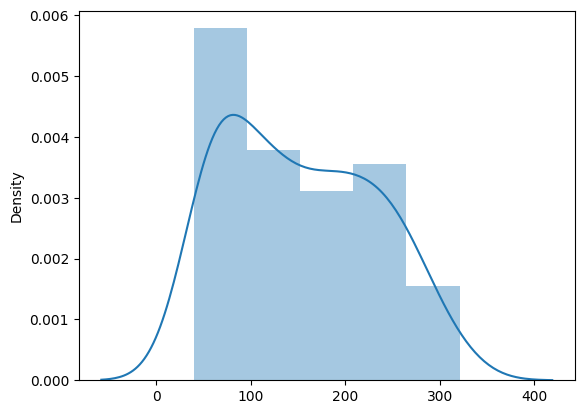

In [14]:
import seaborn as sns
sns.distplot(diabetes_y_test)
pd.DataFrame(data=diabetes_y_test, columns=["values"]).describe()

### Vẽ biểu đồ phân phối cho chỉ số dự đoán của mô hình linear regression

/var/folders/bh/7kzygvtn6x30__50tzq3zdjc0000gn/T/ipykernel_19331/1450655779.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diabetes_y_pred)


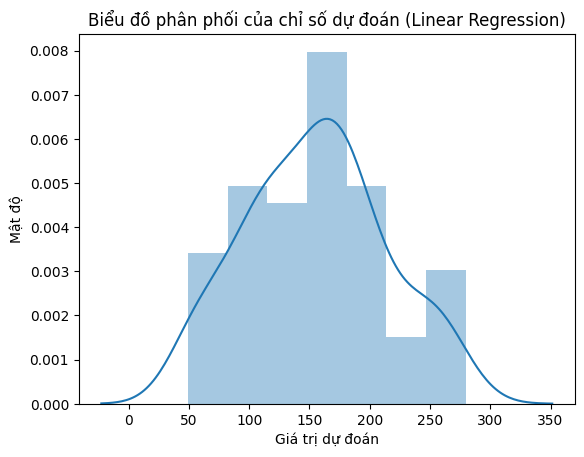

--- Thống kê mô tả giá trị dự đoán (Linear Regression) ---
           values
count   80.000000
mean   155.501049
std     57.511599
min     49.193721
25%    112.399159
50%    161.143223
75%    191.047878
max    279.598577


In [15]:
##### exercise #####
# Yêu cầu: Tính các chỉ số thống kê và vẽ biểu đồ phân phối của chỉ số dự đoán bằng mô hình Linear Regression, quan sát và nhận xét
# Gợi ý: sử dụng sns và pd
######################

# Vẽ biểu đồ phân phối cho chỉ số dự đoán
sns.distplot(diabetes_y_pred)
plt.title("Biểu đồ phân phối của chỉ số dự đoán (Linear Regression)")
plt.xlabel("Giá trị dự đoán")
plt.ylabel("Mật độ")
plt.show()

# Hiển thị các chỉ số thống kê mô tả của chỉ số dự đoán
print("--- Thống kê mô tả giá trị dự đoán (Linear Regression) ---")
print(pd.DataFrame(data=diabetes_y_pred, columns=["values"]).describe())

### Vẽ biểu đồ so sánh kết quả dự đoán và thực tế

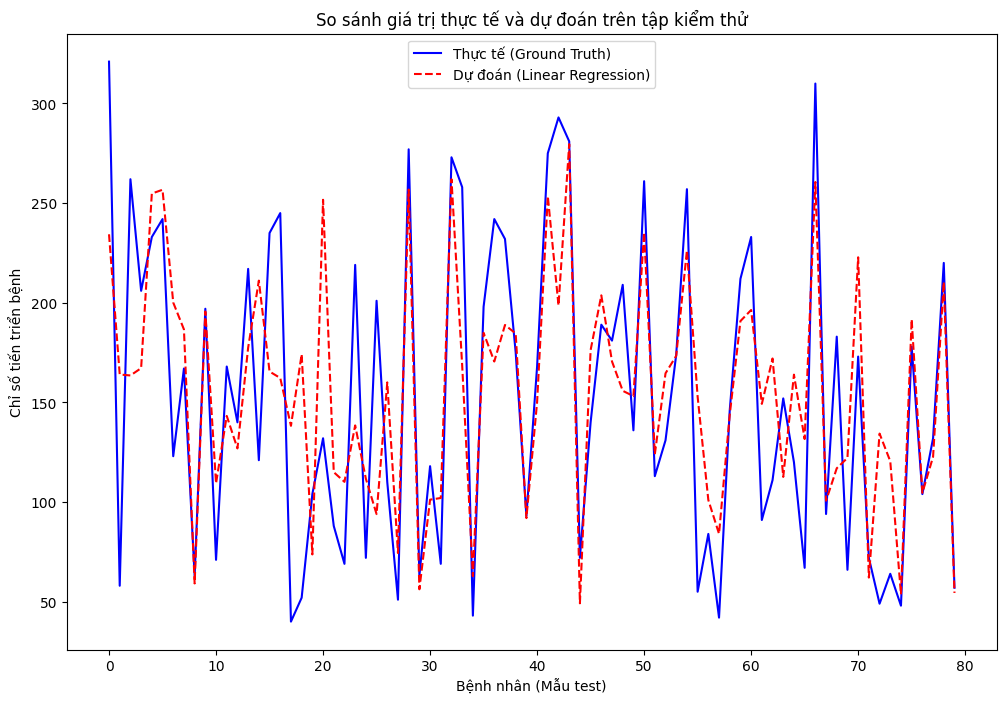

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.plot(diabetes_y_test, label="Thực tế (Ground Truth)", color="blue")
plt.plot(diabetes_y_pred, label="Dự đoán (Linear Regression)", color="red", linestyle="--")

plt.title("So sánh giá trị thực tế và dự đoán trên tập kiểm thử")
plt.xlabel("Bệnh nhân (Mẫu test)")
plt.ylabel("Chỉ số tiến triển bệnh")
plt.legend()

# function to show the plot
plt.show()

## 2.7 Bảng so sánh tổng hợp: Ordinary Least Squares, Ridge và LASSO
Dưới đây là bảng đối chiếu trọng số ($w$) và độ đo đánh giá lỗi kiểm thử ($\text{RMSE}$, $R^2$) giữa 3 mô hình OLS, Ridge ($\alpha = 0.1$) và LASSO ($\alpha = 0.1$) theo đúng cấu trúc Slide bài giảng (Slide 23 - OLS, Ridge, LASSO).

In [17]:
# ===============================================================
# BẢNG TỔNG HỢP: ORDINARY LEAST SQUARES, RIDGE VÀ LASSO
# (Tương ứng cấu trúc bảng Slide 23 trong bài giảng L3 - Linear Regression)
# ===============================================================

feature_names = ['Age', 'Sex', 'BMI', 'BP', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6']

# 1. Huấn luyện 3 mô hình
model_ols = linear_model.LinearRegression().fit(diabetes_X_train, diabetes_y_train)
model_ridge = linear_model.Ridge(alpha=0.1).fit(diabetes_X_train, diabetes_y_train)
model_lasso = linear_model.Lasso(alpha=0.1).fit(diabetes_X_train, diabetes_y_train)

# 2. Dự đoán trên tập kiểm thử
y_pred_ols = model_ols.predict(diabetes_X_test)
y_pred_ridge = model_ridge.predict(diabetes_X_test)
y_pred_lasso = model_lasso.predict(diabetes_X_test)

# 3. Tạo bảng dữ liệu so sánh trọng số w
table_rows = []
table_rows.append({
    'Thuộc tính (w)': 'w0 (Hệ số chặn / Intercept)',
    'Ordinary Least Squares': round(model_ols.intercept_, 4),
    'Ridge (alpha=0.1)': round(model_ridge.intercept_, 4),
    'LASSO (alpha=0.1)': round(model_lasso.intercept_, 4)
})

for name, w_ols, w_ridge, w_lasso in zip(feature_names, model_ols.coef_, model_ridge.coef_, model_lasso.coef_):
    table_rows.append({
        'Thuộc tính (w)': name,
        'Ordinary Least Squares': round(w_ols, 4),
        'Ridge (alpha=0.1)': round(w_ridge, 4),
        'LASSO (alpha=0.1)': round(w_lasso, 4)
    })

# Thêm hàng đánh giá độ đo sai số Test RMSE và Test R2
table_rows.append({
    'Thuộc tính (w)': '--- Test RMSE ---',
    'Ordinary Least Squares': round(math.sqrt(mean_squared_error(diabetes_y_test, y_pred_ols)), 4),
    'Ridge (alpha=0.1)': round(math.sqrt(mean_squared_error(diabetes_y_test, y_pred_ridge)), 4),
    'LASSO (alpha=0.1)': round(math.sqrt(mean_squared_error(diabetes_y_test, y_pred_lasso)), 4)
})

table_rows.append({
    'Thuộc tính (w)': '--- Test R2 Score ---',
    'Ordinary Least Squares': round(r2_score(diabetes_y_test, y_pred_ols), 4),
    'Ridge (alpha=0.1)': round(r2_score(diabetes_y_test, y_pred_ridge), 4),
    'LASSO (alpha=0.1)': round(r2_score(diabetes_y_test, y_pred_lasso), 4)
})

df_comparison = pd.DataFrame(table_rows)

print("=== BẢNG SO SÁNH TRỌNG SỐ VÀ ĐỘ ĐO LỖI (OLS vs RIDGE vs LASSO) ===")
display(df_comparison)

# Nhận xét tự động
zero_features = [name for name, w in zip(feature_names, model_lasso.coef_) if abs(w) < 1e-6]
print("\n[Nhận xét quan trọng]:")
print(f"1. LASSO (L1 regularization) đã tự động triệt tiêu các trọng số về 0 đối với {len(zero_features)} thuộc tính: {zero_features} (Feature Selection).")
print("2. Ridge (L2 regularization) giúp co mạnh các trọng số lớn do hiện tượng đa cộng tuyến (ví dụ: S1 giảm từ -639.80 xuống -64.85).")

=== BẢNG SO SÁNH TRỌNG SỐ VÀ ĐỘ ĐO LỖI (OLS vs RIDGE vs LASSO) ===


,Thuộc tính (w),Ordinary Least Squares,Ridge (alpha=0.1),LASSO (alpha=0.1)
0,w0 (Hệ số chặn / Intercept),152.5604,152.5740,152.5594
1,Age,-0.0113,10.5152,0.0000
2,Sex,-249.7825,-215.2195,-167.1856
3,BMI,518.8022,477.0458,512.0912
4,BP,297.2205,275.1855,248.7017
5,S1,-639.8022,-64.8452,-51.1634
6,S2,356.3305,-82.8446,-0.0000
7,S3,27.7834,-194.2247,-210.2933
8,S4,146.9628,112.9956,0.0000
9,S5,690.4750,427.1900,483.7731



[Nhận xét quan trọng]:
1. LASSO (L1 regularization) đã tự động triệt tiêu các trọng số về 0 đối với 3 thuộc tính: ['Age', 'S2', 'S4'] (Feature Selection).
2. Ridge (L2 regularization) giúp co mạnh các trọng số lớn do hiện tượng đa cộng tuyến (ví dụ: S1 giảm từ -639.80 xuống -64.85).
